In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

netid = 'sk2153'
bucket_name = f'dsan6000-{netid}'
s3_prefix = 'wikipedia-hourly'

In [2]:
import boto3

s3 = boto3.client('s3')
response = s3.list_objects_v2(Bucket=bucket_name, Prefix=s3_prefix + '/')
keys = [obj['Key'] for obj in response['Contents']]
keys = sorted(keys)
print(f"Found {len(keys)} files")

Found 24 files


In [3]:
dfs = []
for key in keys:
    uri = f"s3://{bucket_name}/{key}"
    hour_df = pd.read_parquet(uri)
    dfs.append(hour_df)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
df.head()

(119708, 29)


,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


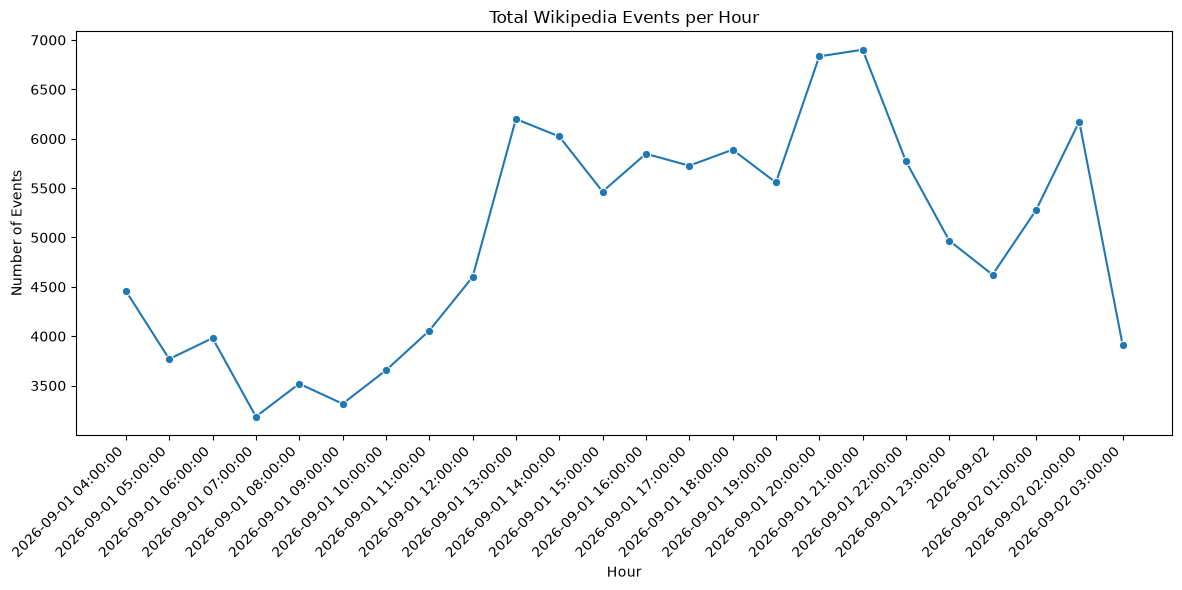

In [4]:
events_per_hour = df.groupby('file_ts').size().reset_index(name='event_count')
events_per_hour = events_per_hour.sort_values('file_ts')

plt.figure(figsize=(12, 6))
sns.lineplot(data=events_per_hour, x='file_ts', y='event_count', marker='o')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Hour')
plt.ylabel('Number of Events')
plt.title('Total Wikipedia Events per Hour')
plt.tight_layout()

plt.savefig('images/hourly-events.svg')
plt.savefig('images/hourly-events.png')
plt.show()

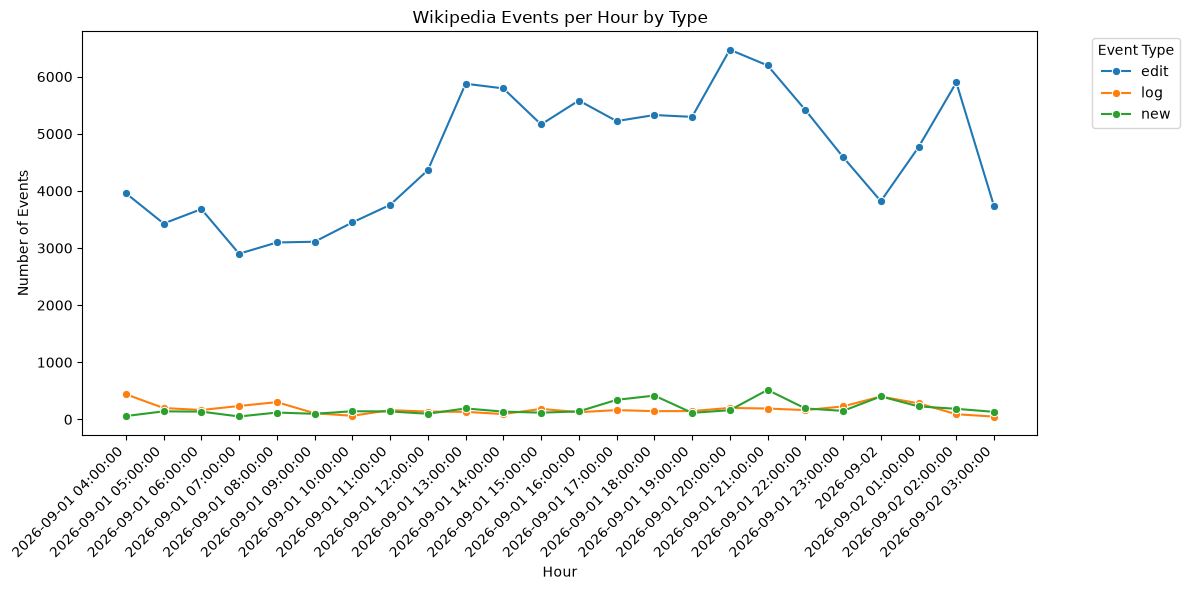

In [5]:
events_by_type = df.groupby(['file_ts', 'type']).size().reset_index(name='event_count')
events_by_type = events_by_type.sort_values('file_ts')

plt.figure(figsize=(12, 6))
sns.lineplot(data=events_by_type, x='file_ts', y='event_count', hue='type', marker='o')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Hour')
plt.ylabel('Number of Events')
plt.title('Wikipedia Events per Hour by Type')
plt.legend(title='Event Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('images/events-by-type.svg')
plt.savefig('images/events-by-type.png')
plt.show()